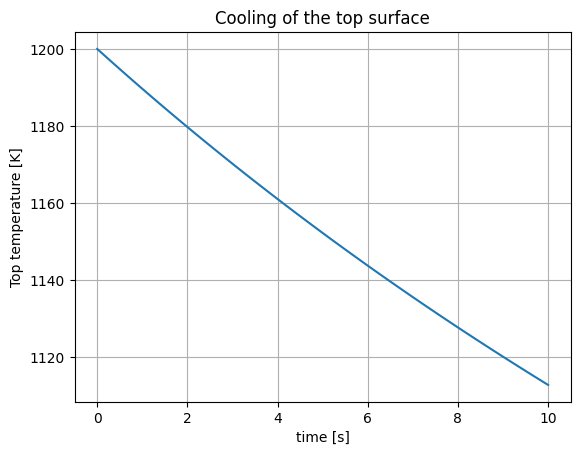

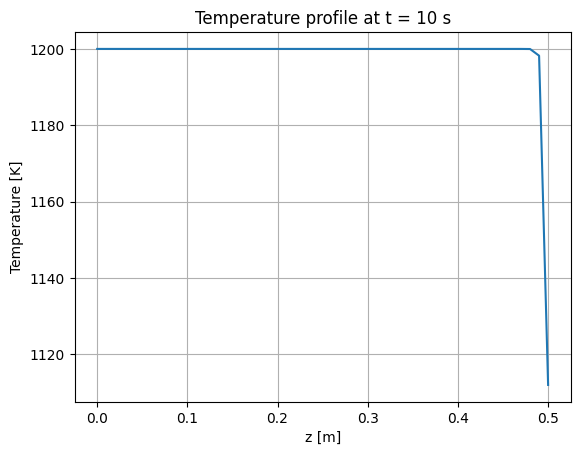

Top temperature after 10 s: 1111.974582724534 K


In [2]:
import numpy as np
import matplotlib.pyplot as plt

H = 0.5
rho = 2.48e3
c = 840
kappa = 0.81

T0 = 1200
TB = 1200
Tinf = 300

w = 5
sigma = 5.67e-8
eps = 0.9

N = 50
dz = H / N
z = np.linspace(0, H, N + 1)

dt = 0.1
t_end = 10
steps = int(t_end / dt)

u = np.ones(N + 1) * T0

times = []
top_temp = []

for k in range(steps + 1):
    times.append(k * dt)
    top_temp.append(u[-1])

    u_new = u.copy()

    u_new[0] = TB

    for i in range(1, N):
        u_new[i] = u[i] + dt * kappa / (rho * c) * (u[i-1] - 2*u[i] + u[i+1]) / dz**2

    q = w * (u[-1] - Tinf) + sigma * eps * (u[-1]**4 - Tinf**4)

    u_ghost = u[N-1] - 2 * dz * q / kappa

    u_new[N] = u[N] + dt * kappa / (rho * c) * (u[N-1] - 2*u[N] + u_ghost) / dz**2

    u = u_new

plt.plot(times, top_temp)
plt.xlabel("time [s]")
plt.ylabel("Top temperature [K]")
plt.title("Cooling of the top surface")
plt.grid(True)
plt.show()

plt.plot(z, u)
plt.xlabel("z [m]")
plt.ylabel("Temperature [K]")
plt.title("Temperature profile at t = 10 s")
plt.grid(True)
plt.show()

print("Top temperature after 10 s:", u[-1], "K")